In [1]:
import numpy as np
import matplotlib.pyplot as plt

# import energy_landscapes
from propagators_grid import propagate
import test_propagators_grid
import energy_landscapes
import collective_variable_analysis
import collective_variables

import importlib

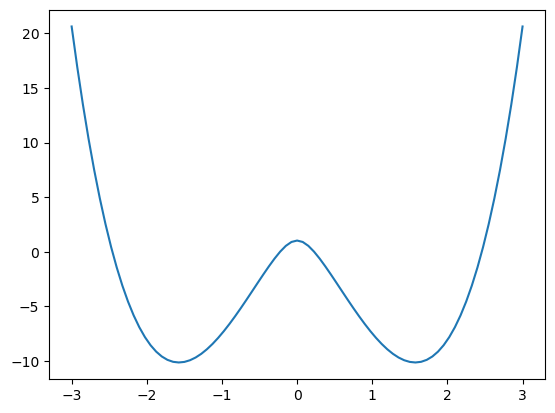

In [10]:

importlib.reload(energy_landscapes)
importlib.reload(collective_variables)

n_walkers = 4
T=1
kB=1
kT = kB*T


sim_system = energy_landscapes.diagonal_2well_2d_system

CV = collective_variables.cv_coord0_2d_coord_1d_cv


cv_grid, free_energy_grid = collective_variable_analysis.free_energy_on_cv_grid(
        free_energy_fn=sim_system.G,
        coord_min=sim_system.coord_min,
        coord_max=sim_system.coord_max,
        n_micro_grid=sim_system.grid_n,
        cv_fn=CV.cv_funct,
        cv_min=CV.cv_min,
        cv_max=CV.cv_max,
        n_cv_grid=CV.grid_n,
        kT = kT
    )

plt.plot(cv_grid, free_energy_grid)

In [ ]:
importlib.reload(test_propagators_grid)
importlib.reload(energy_landscapes)

#test_propagators_grid.test_propagators_grid()
test_propagators_grid.test_free_energy_on_cv_grid()

In [ ]:
importlib.reload(test_propagators_grid)
importlib.reload(energy_landscapes)

n_walkers = 4
n_dim = 2
n_cv = 1

xi = 1

def G1(x):
    return (x[:, 0]**2 - 3)**2 + 0.5*x[:, 1]**2

def G2(x):
    return 0.5*(x[:, 0]**2 + x[:, 1]**2)**2 + (x[:,0]*x[:,1])*10

def G(x):
    return G2(x)

def CV(x):
    return x[:, :1]

def grad_CV(x):
    n = x.shape[0]
    out = np.zeros((n, n_cv, n_dim))
    out[:, 0, 0] = 1.0
    return out

grid_n = 81
cv_min = np.array([-3.0])
cv_max = np.array([3.0])

print(np.array([cv_min[0], cv_min[0]]))
print(np.array([cv_max[0], cv_max[0]]))

cv_grid, free_energy_grid = collective_variables.free_energy_on_cv_grid(
        free_energy_fn=G,
        cv_fn=CV,
        coord_min=np.array([cv_min[0], cv_min[0]]),
        coord_max=np.array([cv_max[0], cv_max[0]]),
        cv_min=cv_min,
        cv_max=cv_max,
        n_cv_grid=grid_n,
        n_micro_grid=grid_n,
        kT = 1
    )

plt.plot(cv_grid, free_energy_grid)

init_coords = np.random.uniform(-1.5, 1.5, size=(n_walkers, n_dim))
init_potentials = np.zeros((n_walkers, grid_n))
sigma = np.array([0.2])

test_propagators_grid.plot_G_surface(G, x_limits = ((cv_min[0], cv_max[0]), (cv_min[0], cv_max[0])), n=200, center=None, slice_axis=0)


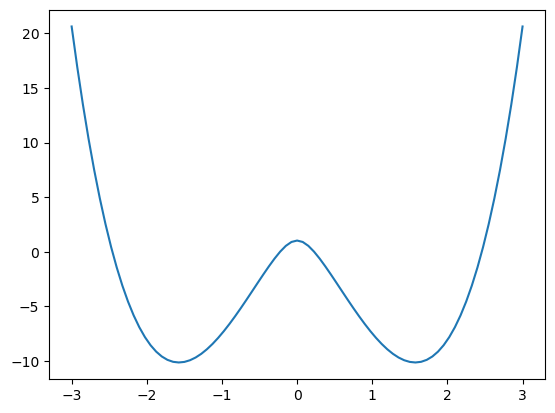

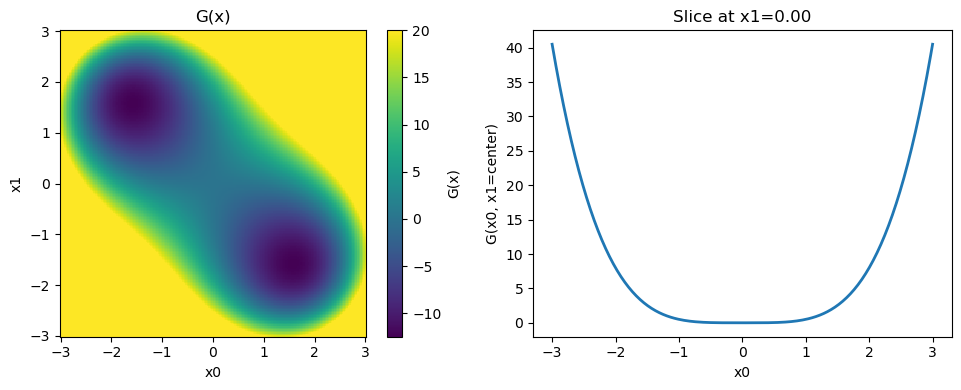

trajectories shape (4, 3000, 2)
potentials shape (4, 300, 81)
sample final coords [[-2.08993704  0.91232692]
 [-0.3863644   1.15557079]
 [ 1.72772751 -1.43799515]
 [-0.04255675 -0.66459487]]
True True
(2,)


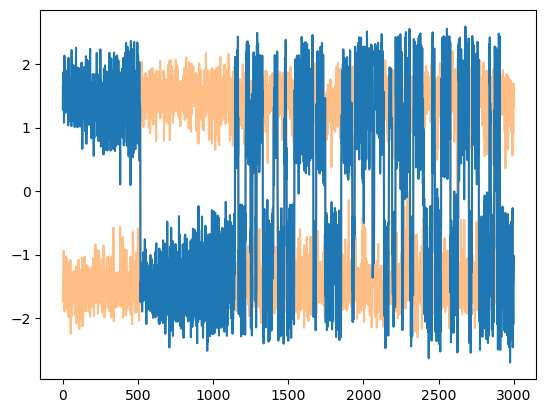

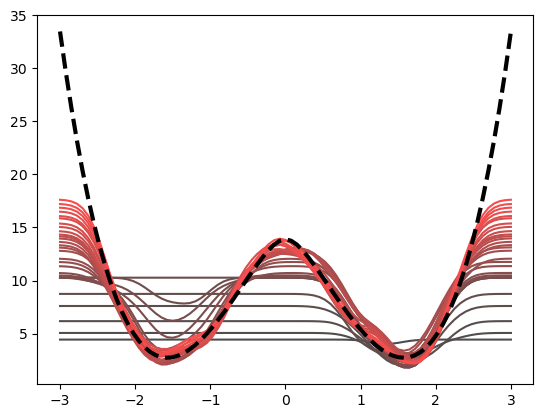

(2,)


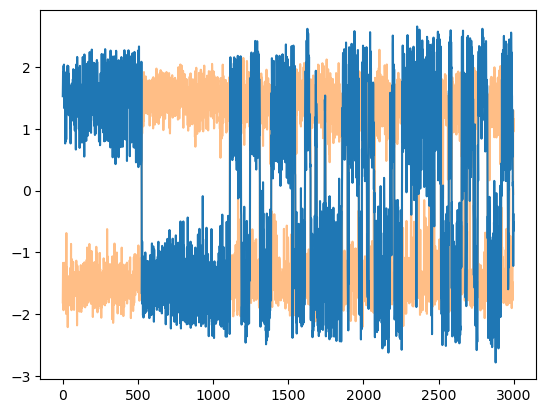

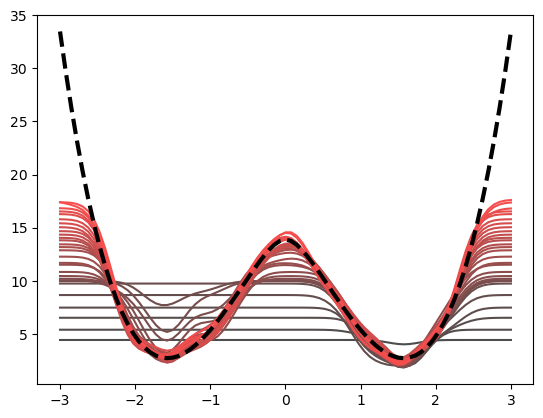

In [11]:

importlib.reload(energy_landscapes)
importlib.reload(collective_variables)

n_walkers = 4
#n_dim = 2
#n_cv = 1
T=1
kB=1
kT = kB*T
# xi= 1

# def G1(x):
#     return (x[:, 0]**2 - 3)**2 + 0.5*x[:, 1]**2

# def G2(x):
#     return 0.5*(x[:, 0]**2 + x[:, 1]**2)**2 + (x[:,0]*x[:,1])*10

# def G(x):
#     return G2(x)

sim_system = energy_landscapes.diagonal_2well_2d_system

CV = collective_variables.cv_coord0_2d_coord_1d_cv
# def CV(x):
#     return x[:, :1]

# def grad_CV(x):
#     n = x.shape[0]
#     out = np.zeros((n, n_cv, n_dim))
#     out[:, 0, 0] = 1.0
#     return out

#grid_n = 81
#cv_min = np.array([-3.0])
#cv_max = np.array([3.0])

cv_grid, free_energy_grid = collective_variable_analysis.free_energy_on_cv_grid(
        free_energy_fn=sim_system.G,
        coord_min=sim_system.coord_min,
        coord_max=sim_system.coord_max,
        n_micro_grid=sim_system.grid_n,
        cv_fn=CV.cv_funct,
        cv_min=CV.cv_min,
        cv_max=CV.cv_max,
        n_cv_grid=CV.grid_n,
        kT = kT
    )

plt.plot(cv_grid, free_energy_grid)


init_coords = np.random.uniform(-1.5, 1.5, size=(n_walkers, sim_system.n_dim))
init_potentials = np.zeros((n_walkers, CV.grid_n))

sigma = np.array([0.2])
delta_T = 40
omega = 0.4

test_propagators_grid.plot_G_surface(sim_system.G, x_limits = ((sim_system.coord_min[0], sim_system.coord_max[0]), (sim_system.coord_min[1], sim_system.coord_max[1])), n=200, center=None, slice_axis=0)


traj, pots = propagate(
    G=sim_system.G, kT=kT, dt=0.01, xi = sim_system.xi, init_coords=init_coords,
    init_potentials=init_potentials, steps_per_saved_frame=100,
    n_gaussians=300, frames_per_gaussian=10,
    CV=CV.cv_funct, grad_CV=CV.cv_grad_funct, sigma=sigma, omega=omega, delta_T=delta_T,
    cv_min=CV.cv_min, cv_max=CV.cv_max
)

print('trajectories shape', traj.shape)
print('potentials shape', pots.shape)
print('sample final coords', traj[:, -1, :])
#print('max bias height walker0 over time', pots[0, :, :].max(axis=-1))
print(np.isfinite(traj).all(), np.isfinite(pots).all())


def plot_trj(trj, pot):
    global kB
    global T
    kT=kB*T
    
    print(trj[0].shape)
    plt.plot(trj[:,0], zorder=100)
    plt.plot(trj[:,1], alpha=0.5)
    plt.show()

    for i, Vi in enumerate(pot):
        if i%10==0:
            plt.plot(cv_grid, -Vi*(delta_T+T)/delta_T + kT*np.log(np.sum(np.exp(Vi*((delta_T+T)/delta_T)/kT))), color = [0.3+0.7*(i/len(pot)), 0.3, 0.3])

    plt.plot(cv_grid, free_energy_grid + kT*np.log(np.sum(np.exp(-free_energy_grid/kT))), linestyle="dashed", color="black", linewidth="3")

    plt.show()

plot_trj(traj[0], pots[0])
plot_trj(traj[1], pots[1])



In [ ]:
print(traj[0,0].shape)
plt.plot(traj[0,:,0], zorder=100, alpha=0.5)
plt.plot(-traj[0,:,1], alpha=0.5)
plt.show()

for i, Vi in enumerate(pots[0]):
    if i%10==0:
        plt.plot(cv_grid, -Vi*(delta_T+T)/delta_T + kT*np.log(np.sum(np.exp(Vi*((delta_T+T)/delta_T)/kT))), color = [0.3+0.7*(i/len(pots[0])), 0.3, 0.3])

kT=1
plt.plot(cv_grid, free_energy_grid + kT*np.log(np.sum(np.exp(-free_energy_grid/kT))), linestyle="dashed", color="black", linewidth="3")

plt.show()


In [ ]:
# quick 2-cv test
n_cv2 = 2
def CV2(x):
    return x[:, :2]
def grad_CV2(x):
    n = x.shape[0]
    out = np.zeros((n, n_cv2, n_dim))
    out[:, 0, 0] = 1.0
    out[:, 1, 1] = 1.0
    return out

sigma2 = np.array([0.3, 0.3])
grid_shape2 = (25, 25)
init_potentials2 = np.zeros((n_walkers, *grid_shape2))
cv_min2 = np.array([-3.0, -3.0])
cv_max2 = np.array([3.0, 3.0])

traj2, pots2 = propagate(
    G=G, kT=1.0, dt=0.001, init_coords=init_coords,
    init_potentials=init_potentials2, steps_per_saved_frame=5,
    n_gaussians=5, frames_per_gaussian=2,
    CV=CV2, grad_CV=grad_CV2, sigma=sigma2, omega=0.5, delta_T=5.0,
    cv_min=cv_min2, cv_max=cv_max2,
)
print('2cv trajectories shape', traj2.shape)
print('2cv potentials shape', pots2.shape)
print(np.isfinite(traj2).all(), np.isfinite(pots2).all())